In [126]:
'''
    reference from huggingface agents course
    https://huggingface.co/learn/agents-course/unit2/langgraph/first_graph
'''
import re
import os
from dotenv import load_dotenv
from typing import TypedDict, Dict, Optional, List, Any

from langchain_core.messages import HumanMessage
from langgraph.graph import START,END,StateGraph
from langchain_ollama import ChatOllama

In [108]:
load_dotenv("C:/Users/yadhu/PycharmProjects/HuggingFaceAgents/langfuse.env")

True

In [109]:
class EmailState(TypedDict):
    email: Dict[str, any]
    email_category: Optional[str]
    spam_reason: Optional[str]
    is_spam: Optional[bool]
    email_draft: Optional[str]
    messages: List[Dict[str, any]]


In [110]:
llm = ChatOllama(
    model = "qwen2:7b",
    base_url="http://localhost:11434",
    temperature = 0.1
)

In [111]:
def read_email(state: EmailState) -> Optional[Dict]:
    email = state["email"]
    print(f"Alfred is processing an email from {email['sender']} with subject: {email['subject']}")
    return {}

In [112]:
def classify_email(state: EmailState) -> Dict:
    email = state["email"]
    prompt = f"""
    As Alfred the butler, analyze this email and determine if it is spam or legitimate.

    Email:
    From: {email['sender']}
    Subject: {email['subject']}
    Body: {email['body']}

    First, determine if this email is spam. If it is spam, explain why.
    If it is legitimate, categorize it (inquiry, complaint, thank you, etc.).
    the output format should be like
    is_spam: state whether is spam or not
    reason: reason for classifying as spam if spam
    email_category: category of email belonging to either inquiry, complaint, thank you, reequest, information

    """
    messages = [HumanMessage(content= prompt)]
    response = llm.invoke(messages)

    response_text = response.content.lower()
    is_spam = re.search(r"is_spam:\s*(.*)", response_text).group(1).strip()
    spam_reason = re.search(r"reason:\s*(.*)", response_text).group(1).strip()
    email_category = re.search(r"email_category:\s*(.*)", response_text).group(1).strip()
    state["is_spam"] = is_spam in ("yes", "true")

    state["spam_reason"] = spam_reason
    state["email_category"] = email_category
    new_messages = state.get("messages", []) + [
        {"role": "user", "content": prompt},
        {"role": "assistant", "content": response.content}
    ]

    # Return state updates
    return {
        "is_spam": state["is_spam"],
        "spam_reason": spam_reason,
        "email_category": email_category,
        "messages": new_messages
    }

In [113]:
def handle_spam(state: EmailState):
    """Alfred discards spam email with a note"""
    print(f"Alfred has marked the email as spam. Reason: {state['spam_reason']}")
    print("The email has been moved to the spam folder.")

    # We're done processing this email
    return {}

In [114]:
def draft_response(state: EmailState):
    email = state["email"]
    category = state["email_category"] or "general"

    # Prepare our prompt for the LLM
    prompt = f"""
    As Alfred the butler, draft a polite preliminary response to this email.

    Email:
    From: {email['sender']}
    Subject: {email['subject']}
    Body: {email['body']}

    This email has been categorized as: {category}

    Draft a brief, professional response that Mr. Hugg can review and personalize before sending.
    """

    messages = [HumanMessage(content=prompt)]
    response = llm.invoke(messages)

    # Update messages for tracking
    new_messages = state.get("messages", []) + [
        {"role": "user", "content": prompt},
        {"role": "assistant", "content": response.content}
    ]

    # Return state updates
    return {
        "email_draft": response.content,
        "messages": new_messages
    }

In [115]:
def notify_mr_hugg(state: EmailState):
    """Alfred notifies Mr. Hugg about the email and presents the draft response"""
    email = state["email"]

    print("\n" + "="*50)
    print(f"Sir, you've received an email from {email['sender']}.")
    print(f"Subject: {email['subject']}")
    print(f"Category: {state['email_category']}")
    print("\nI've prepared a draft response for your review:")
    print("-"*50)
    print(state["email_draft"])
    print("="*50 + "\n")

    # We're done processing this email
    return {}

In [116]:
def route_email(state: EmailState)-> str:
    if state["is_spam"]:
        return "spam"
    else:
        return "legitimate"

In [117]:
from langfuse.langchain import CallbackHandler

email_graph = StateGraph(EmailState)
email_graph.add_node("read_email", read_email)
email_graph.add_node("classify_email", classify_email)
email_graph.add_node("handle_spam", handle_spam)
email_graph.add_node("draft_response", draft_response)
email_graph.add_node("notify_mr_hugg", notify_mr_hugg)

email_graph.add_edge(START, "read_email")
email_graph.add_edge("read_email", "classify_email")
email_graph.add_conditional_edges(
    "classify_email",
    route_email,
    {
        "spam": "handle_spam",
        "legitimate": "draft_response"
    }
)
email_graph.add_edge("handle_spam", END)
email_graph.add_edge("draft_response", "notify_mr_hugg")
email_graph.add_edge("notify_mr_hugg", END)
compiled_graph = email_graph.compile()


In [118]:
legitimate_email = {
    "sender": "john.smith@example.com",
    "subject": "Question about your services",
    "body": "Dear Mr. Hugg, I was referred to you by a colleague and I'm interested in learning more about your consulting services. Could we schedule a call next week? Best regards, John Smith"
}

# Example spam email
spam_email = {
    "sender": "winner@lottery-intl.com",
    "subject": "YOU HAVE WON $5,000,000!!!",
    "body": "CONGRATULATIONS! You have been selected as the winner of our international lottery! To claim your $5,000,000 prize, please send us your bank details and a processing fee of $100."
}

In [119]:
langfuse_handler = CallbackHandler()
print("\nProcessing legitimate email...")
legitimate_result = compiled_graph.invoke(
    input = {
        "email": spam_email,
        "is_spam": None,
        "spam_reason": None,
        "email_category": None,
        "email_draft": None,
        "messages": []
        },
    config = {
        "callbacks": [langfuse_handler]
    }
)


Processing legitimate email...
Alfred is processing an email from winner@lottery-intl.com with subject: YOU HAVE WON $5,000,000!!!
Alfred has marked the email as spam. Reason: the email claims an unsolicited prize, requests personal financial information (bank details), and demands a processing fee. these are common indicators of spam or phishing attempts.
The email has been moved to the spam folder.


In [90]:
legitimate_result

{'email': {'sender': 'john.smith@example.com',
  'subject': 'Question about your services',
  'body': "Dear Mr. Hugg, I was referred to you by a colleague and I'm interested in learning more about your consulting services. Could we schedule a call next week? Best regards, John Smith"},
 'email_category': 'inquiry',
 'spam_reason': 'the email does not contain any suspicious elements such as urgent requests, threats, or unsolicited attachments. it is addressed properly and has a clear subject line.',
 'is_spam': False,
 'email_draft': "Subject: Confirmation of Inquiry on Consulting Services - Scheduled Call Next Week\n\nDear Mr. Smith,\n\nThank you for reaching out to me regarding my consulting services. I appreciate your colleague's recommendation and am delighted to hear about your interest in discussing how we might collaborate.\n\nI would be more than happy to schedule a call with you next week at your convenience. Please let me know which day(s) work best for you, along with any pre

In [124]:
returned_png = compiled_graph.get_graph().draw_mermaid_png()

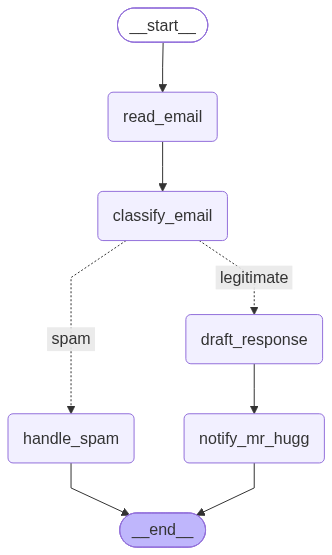

In [125]:
from IPython.display import Image, display

display(Image(returned_png))